First 5 Rows:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date    

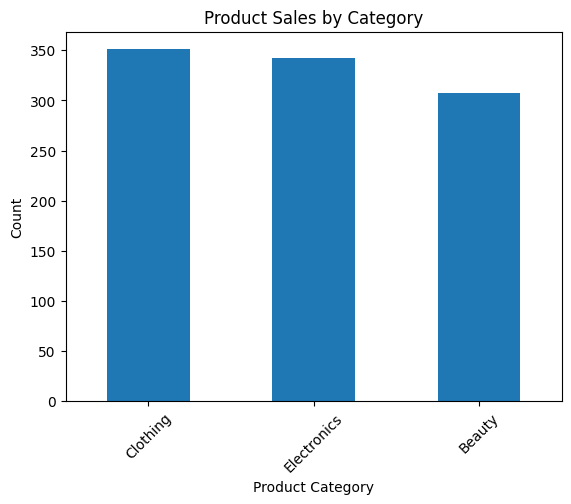


Total Sales by Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


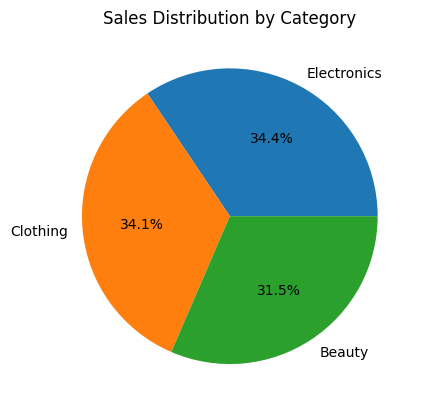

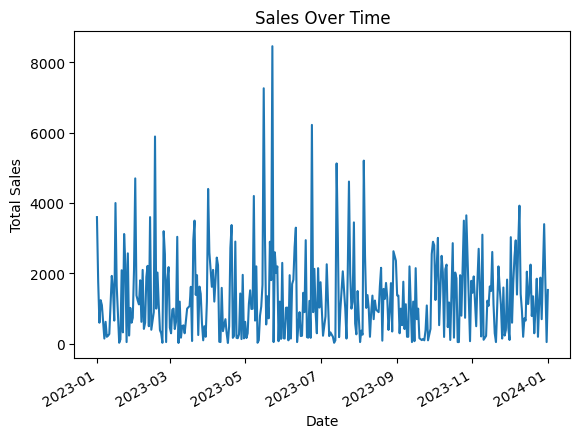


Top 5 Highest Sales:
     Transaction ID       Date Customer ID  Gender  Age Product Category  \
945             946 2023-05-08     CUST946    Male   62      Electronics   
71               72 2023-05-23     CUST072  Female   20      Electronics   
14               15 2023-01-16     CUST015  Female   42      Electronics   
576             577 2023-02-13     CUST577    Male   21           Beauty   
571             572 2023-04-20     CUST572    Male   31         Clothing   

     Quantity  Price per Unit  Total Amount  
945         4             500          2000  
71          4             500          2000  
14          4             500          2000  
576         4             500          2000  
571         4             500          2000  


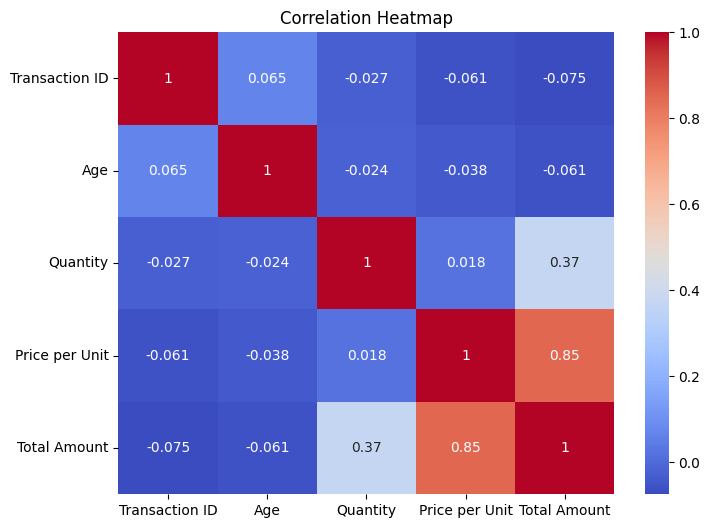

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("retail_sales_dataset.csv")

print("First 5 Rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nColumn Names:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

data.dropna(inplace=True)

print("\nStatistical Summary:")
print(data.describe())

print("\nProduct Category Count:")
print(data['Product Category'].value_counts())

data['Product Category'].value_counts().plot(kind='bar')
plt.title("Product Sales by Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

category_sales = data.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print("\nTotal Sales by Category:")
print(category_sales)

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Category")
plt.ylabel("")
plt.show()

data['Date'] = pd.to_datetime(data['Date'])

daily_sales = data.groupby('Date')['Total Amount'].sum()

daily_sales.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

print("\nTop 5 Highest Sales:")
print(data.sort_values(by='Total Amount', ascending=False).head())

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
